# Tangent-space FC benchmark and B-to-A transfer

**Author:** Jaime · **Date:** 19 July 2026 · **Status:** sandbox candidate, not promoted.

## Question

Does an off-diagonal log-Euclidean tangent representation predict working-memory performance better
than the team's 78-network reconfiguration fingerprint, in subjects the model never saw?

## Design

Three feature sets behind one estimator: the baseline fingerprint, tangent reconfiguration
(2-back minus 0-back) and tangent 2-back alone. All share the event windows, target, folds, scaling
and RidgeCV grid, so any difference between them is the representation.

Adoption requires reproducing the audited internal reference values, beating the permutation null
both internally and externally, and staying at least competitive with the baseline in
identity-disjoint B-to-A transfer.

Reusable code lives in the sandbox layer (`datasets` -> `preprocessing` -> `connectivity` ->
`evaluation`); this notebook owns only the experiment orchestration.

In [1]:
# Setup: paths, imports, and fixed configuration
from __future__ import annotations

import gc
import json
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import norm
from sklearn.base import clone
from sklearn.model_selection import KFold, cross_val_predict

NOTEBOOK_STARTED = time.perf_counter()

CWD = Path.cwd().resolve()
ROOT = next((candidate for candidate in [CWD, CWD / "project" / "fmri" / "the-gammas", *CWD.parents]
             if (candidate / "sandbox" / "jaime" / "datasets.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Could not locate the The-Gammas repository root")
JAIME = ROOT / "sandbox" / "jaime"
if str(JAIME) not in sys.path:
    sys.path.insert(0, str(JAIME))

import connectivity as fc
import datasets as ds
import evaluation as ev
import preprocessing as pp

DATA = Path(os.environ.get("GAMMAS_DATA_DIR", ROOT / "data")).resolve()
CACHE = Path(os.environ.get("TANGENT_CACHE_DIR", DATA / "tangent_benchmark_cache")).resolve()
ARTIFACTS = JAIME / "artifacts_staging" / "tangent_benchmark"
A, B = ds.spec_a(DATA), ds.spec_b(DATA)

HRF_DELAY = 4.0
N_EDGES = ds.N_PARCELS * (ds.N_PARCELS - 1) // 2
SEEDS = tuple(range(int(os.environ.get("TANGENT_N_SEEDS", "20"))))
N_PERM = int(os.environ.get("TANGENT_N_PERM", "1000"))
N_BOOT = int(os.environ.get("TANGENT_N_BOOT", "2000"))
FORCE_REBUILD = os.environ.get("TANGENT_FORCE_REBUILD", "0") == "1"
# A reduced run stays possible for smoke-testing, but is stamped everywhere it is reported so a
# partial protocol can never be mistaken for the adoption evidence.
PROTOCOL = "full" if (len(SEEDS), N_PERM, N_BOOT) == (20, 1000, 2000) else "REDUCED (smoke test)"

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
CONFIG = {"protocol": PROTOCOL, "hrf_delay_seconds": HRF_DELAY, "cv_seeds": len(SEEDS),
          "permutations": N_PERM, "bootstrap_resamples": N_BOOT, "force_rebuild": FORCE_REBUILD}
CONFIG

{'protocol': 'full',
 'hrf_delay_seconds': 4.0,
 'cv_seeds': 20,
 'permutations': 1000,
 'bootstrap_resamples': 2000,
 'force_rebuild': False}

In [2]:
# ID-free cache: positional feature/target arrays and boolean masks, never identities
CACHE_VERSION = 2
N_TARGET, N_NONTARGET = 16, 64


def corrected_dprime(hit: float, false_alarm: float) -> float:
    """d' with the prespecified 1/(2N) clipping for HCP's 16 target / 64 non-target trials."""
    return float(norm.ppf(np.clip(hit, 1 / (2 * N_TARGET), 1 - 1 / (2 * N_TARGET)))
                 - norm.ppf(np.clip(false_alarm, 1 / (2 * N_NONTARGET), 1 - 1 / (2 * N_NONTARGET))))


def target_arrays(spec: ds.DatasetSpec, subjects: list[str]) -> dict[str, np.ndarray]:
    """Targets aligned to the deterministic subject order the feature rows use."""
    behaviour = pp.behaviour_table(spec).set_index("subject").loc[subjects]
    arrays = {"y_acc": behaviour["acc_2bk"].to_numpy(float),
              "acc0": behaviour["acc_0bk"].to_numpy(float)}
    if spec.kind == "B":
        sdt = pp.signal_detection_table(spec).set_index("subject").loc[subjects]
        arrays["y_dprime"] = np.array([corrected_dprime(hit, fa) for hit, fa
                                       in zip(sdt["hit_2bk"], sdt["fa_2bk"], strict=True)])
    return arrays


def split_masks(subjects: list[str], split: dict) -> tuple[np.ndarray, np.ndarray]:
    """Convert the canonical ID split to positional masks, so no identity is ever cached."""
    position = {subject: index for index, subject in enumerate(subjects)}
    masks = []
    for key in ("train", "test"):
        mask = np.zeros(len(subjects), dtype=bool)
        mask[[position[subject] for subject in split[key]]] = True
        masks.append(mask)
    if np.any(masks[0] & masks[1]) or not np.all(masks[0] | masks[1]):
        raise ValueError("canonical split is not disjoint and exhaustive")
    return masks[0], masks[1]


def identity_disjoint_mask(a_subjects: list[str], b_subjects: list[str],
                           spec_b: ds.DatasetSpec) -> tuple[np.ndarray, dict[str, int]]:
    """Positional B-only mask; real identities are read in memory and never stored or printed."""
    original_ids = (spec_b.behaviour.parents[1] / "orig_ids.txt").read_text().split()
    if len(original_ids) <= max(int(subject) for subject in b_subjects):
        raise ValueError("B identity map does not cover every analytic row")
    b_real = [original_ids[int(subject)] for subject in b_subjects]
    if len(set(b_real)) != len(b_real):
        raise ValueError("B identity mapping is not one-to-one")
    a_set = set(a_subjects)
    b_only = np.array([identity not in a_set for identity in b_real])
    return b_only, {"n_a": len(a_subjects), "n_b": len(b_subjects),
                    "n_overlap": len(a_set.intersection(b_real)), "n_b_only": int(b_only.sum())}


def frame_checks(spec: ds.DatasetSpec, subject: str) -> dict[str, int]:
    """Delayed-frame invariants for one probe subject, aggregate counts only."""
    checks = {}
    for run in (0, 1):
        frames = {level: pp.condition_frames(spec, subject, run, level, delay=HRF_DELAY)
                  for level in ("0back", "2back")}
        checks[f"run{run}_0back"] = int(frames["0back"].size)
        checks[f"run{run}_2back"] = int(frames["2back"].size)
        checks[f"run{run}_overlap"] = int(np.intersect1d(*frames.values()).size)
    return checks


def dataset_features(spec: ds.DatasetSpec, subjects: list[str],
                     network_labels: np.ndarray) -> dict[str, np.ndarray]:
    """Baseline fingerprints and packed condition covariances, in subject order."""
    n, width = len(subjects), ds.N_PARCELS * (ds.N_PARCELS + 1) // 2
    out = {"fp0": np.empty((n, 78), np.float32), "fp2": np.empty((n, 78), np.float32),
           # float64 on purpose: a float32 round-trip can push a near-boundary SPD covariance
           # indefinite before the matrix logarithm.
           "cov0": np.empty((n, width)), "cov2": np.empty((n, width))}
    for index, subject in enumerate(subjects):
        low, high = (pp.condition_timeseries(spec, subject, level, delay=HRF_DELAY)
                     for level in ("0back", "2back"))
        out["fp0"][index] = fc.network_fingerprint(np.corrcoef(low), network_labels)
        out["fp2"][index] = fc.network_fingerprint(np.corrcoef(high), network_labels)
        out["cov0"][index], out["cov2"][index] = fc.pack_triangle(fc.subject_covariances([low, high]))
        if (index + 1) % 50 == 0 or index + 1 == n:
            print(f"  built {index + 1}/{n} feature rows")
    return out


def cache_manifest() -> dict[str, object]:
    """Configuration a cache must match before it may be reused."""
    return {"cache_version": CACHE_VERSION, "hrf_delay_seconds": HRF_DELAY, "tr_seconds": ds.TR,
            "n_roi": ds.N_PARCELS, "n_a": 100, "n_b": 336, "n_overlap": 35,
            "n_b_only": 301, "n_train": 269, "n_test": 67}


def load_cached(name: str) -> dict[str, np.ndarray] | None:
    """Cached arrays when the stored manifest matches this configuration, else None."""
    path, manifest_path = CACHE / f"dataset_{name}.npz", CACHE / "manifest.json"
    if FORCE_REBUILD or not (path.exists() and manifest_path.exists()):
        return None
    stored = json.loads(manifest_path.read_text())
    if any(stored.get(key) != value for key, value in cache_manifest().items()):
        return None
    with np.load(path, allow_pickle=False) as archive:
        return {key: archive[key] for key in archive.files}


def save_cache(name: str, arrays: dict[str, np.ndarray], **manifest_extra: object) -> None:
    """Write one complete cache file before replacing its target, then update the manifest."""
    CACHE.mkdir(parents=True, exist_ok=True)
    path = CACHE / f"dataset_{name}.npz"
    temporary = path.with_suffix(".tmp.npz")
    np.savez_compressed(temporary, **arrays)
    temporary.replace(path)
    manifest_path = CACHE / "manifest.json"
    stored = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}
    manifest_path.write_text(json.dumps({**stored, **cache_manifest(), **manifest_extra}, indent=2))

## 1. Data preparation and cache

Features are built once from the raw time series and cached as positional arrays and boolean masks:
real HCP identities are read in memory to remove the B/A overlap, never stored or printed.

In [3]:
# Build or load B; A stays gated on the internal reproduction result
cache_started = time.perf_counter()
B_SUBJECTS = ds.load_subjects(B)
NETWORK_LABELS = pp.region_table(B).sort_values("roi_index")["network"].to_numpy()

B_DATA = load_cached("b")
if B_DATA is None:
    print("Building dataset B from delayed condition time series")
    b_only, overlap = identity_disjoint_mask(ds.load_subjects(A), B_SUBJECTS, B)
    train_mask, test_mask = split_masks(B_SUBJECTS, ev.make_split(B, seed=42, test_frac=0.2, cv_folds=5))
    B_DATA = {**dataset_features(B, B_SUBJECTS, NETWORK_LABELS), **target_arrays(B, B_SUBJECTS),
              "train_mask": train_mask, "test_mask": test_mask, "b_only_mask": b_only}
    save_cache("b", B_DATA, frame_checks_b=frame_checks(B, B_SUBJECTS[0]), **overlap)
else:
    print("Reusing B cache with a matching manifest")
MANIFEST = json.loads((CACHE / "manifest.json").read_text())

# Hard data, split and alignment checks
checks = MANIFEST["frame_checks_b"]
assert all(value == 156 for key, value in checks.items() if not key.endswith("overlap"))
assert all(value == 0 for key, value in checks.items() if key.endswith("overlap"))
assert B_DATA["fp0"].shape == (336, 78) and B_DATA["cov0"].shape == (336, 64_980)
assert int(B_DATA["train_mask"].sum()) == 269 and int(B_DATA["test_mask"].sum()) == 67
assert not np.any(B_DATA["train_mask"] & B_DATA["test_mask"])
assert int(B_DATA["b_only_mask"].sum()) == 301 and MANIFEST["n_overlap"] == 35
assert all(np.isfinite(B_DATA[key]).all() for key in ("fp0", "fp2", "y_acc", "acc0", "y_dprime"))

target_r = ev.correlation(B_DATA["y_acc"], B_DATA["y_dprime"])
assert abs(target_r - 0.9451) <= 0.01
pd.DataFrame([("B analytic", 336), ("canonical train", 269), ("canonical test", 67),
              ("B-only external train", 301), ("A external test", 100), ("A/B overlap removed", 35),
              ("fingerprint features", 78), ("tangent edge features", N_EDGES),
              ("corr(acc_2bk, d-prime)", round(target_r, 4)),
              ("cache seconds", round(time.perf_counter() - cache_started, 1))],
             columns=["check", "value"])

Reusing B cache with a matching manifest


,check,value
0,B analytic,336.0000
1,canonical train,269.0000
2,canonical test,67.0000
3,B-only external train,301.0000
4,A external test,100.0000
5,A/B overlap removed,35.0000
6,fingerprint features,78.0000
7,tangent edge features,64620.0000
8,"corr(acc_2bk, d-prime)",0.9451
9,cache seconds,1.2000


## 2. Log-Euclidean edges

Ledoit-Wolf shrinkage is required because each condition has fewer frames (312) than ROIs (360).
Matrix logs are subject-local, so they are computed once here; only the tangent reference is
fold-dependent, and it is fitted inside each pipeline from training rows alone.

In [4]:
def log_edges(data: dict[str, np.ndarray], label: str) -> np.ndarray:
    """Cache rows -> ``[0back | 2back]`` log-edge columns, releasing the packed source."""
    started = time.perf_counter()
    edges = np.hstack([fc.log_triangles(data.pop("cov0"), ds.N_PARCELS),
                       fc.log_triangles(data.pop("cov2"), ds.N_PARCELS)])
    gc.collect()
    print(f"{label}: {edges.shape} in {time.perf_counter() - started:.1f}s")
    return edges


STACK_B = log_edges(B_DATA, "B log edges")
assert STACK_B.shape == (336, 2 * N_EDGES) and np.isfinite(STACK_B).all()

B log edges: (336, 129240) in 15.4s


In [5]:
# One estimator, three feature sets: every difference below is the representation
TRAIN_IDX, TEST_IDX = np.flatnonzero(B_DATA["train_mask"]), np.flatnonzero(B_DATA["test_mask"])


def methods(stack: np.ndarray, fingerprint_reconfig: np.ndarray) -> dict:
    """Feature matrix, pipeline and feature count per compared method.

    ``stack[:, N_EDGES:]`` is a view, so the 2-back-only variant costs no extra copy of a
    336 x 129,240 matrix.
    """
    return {
        ("Baseline fingerprint", "reconfig(2-0)"): (fingerprint_reconfig, ev.ridge_pipeline(), 78),
        ("Tangent edges", "reconfig(2-0)"): (stack, ev.ridge_pipeline(fc.TangentCentering(paired=True)), N_EDGES),
        ("Tangent edges", "2back"): (stack[:, N_EDGES:], ev.ridge_pipeline(fc.TangentCentering()), N_EDGES),
    }


METHODS = methods(STACK_B, B_DATA["fp2"].astype(float) - B_DATA["fp0"].astype(float))


def repeated_cv(X: np.ndarray, pipeline, y: np.ndarray, seeds: tuple[int, ...] = SEEDS) -> np.ndarray:
    """Out-of-fold predictions, one row per seed; every learned transform refits inside each fold."""
    return np.stack([cross_val_predict(pipeline, X, y, cv=KFold(5, shuffle=True, random_state=seed))
                     for seed in seeds])


def protocol_rows(y: np.ndarray, target_name: str, methods_map: dict = None) -> pd.DataFrame:
    """All methods against one target: repeated CV, canonical held-out fit, null and specificity."""
    rows = []
    for (method, representation), (X, pipeline, n_features) in (methods_map or METHODS).items():
        predictions = repeated_cv(X, pipeline, y)
        cv_r = np.array([ev.correlation(row, y) for row in predictions])
        mean_prediction = predictions.mean(axis=0)
        heldout = clone(pipeline).fit(X[TRAIN_IDX], y[TRAIN_IDX]).predict(X[TEST_IDX])
        rows.append({"method": method, "representation": representation, "target": target_name,
                     "n_features": n_features,
                     "cv_r_mean": float(cv_r.mean()), "cv_r_sd": float(cv_r.std()),
                     "heldout_r": ev.correlation(heldout, y[TEST_IDX]),
                     "perm_p": ev.permutation_p(mean_prediction, y, n_perm=N_PERM),
                     "partial_acc0bk": ev.partial_correlation(mean_prediction, y, B_DATA["acc0"])})
        del predictions, mean_prediction, heldout
        gc.collect()
    return pd.DataFrame(rows)

## 3. Internal benchmark and reproduction gate

Repeated five-fold CV across all 336 B participants, plus a separately fitted 269/67 score. Those 67
labels already participated in method comparison, so that score is not an untouched confirmation;
section 4 is the honest sensitivity check. Execution stops here if the reference values fail.

In [6]:
benchmark_started = time.perf_counter()
INTERNAL_ACC = protocol_rows(B_DATA["y_acc"], "acc_2bk")
display(INTERNAL_ACC.round(4))

GATE = pd.DataFrame([{"check": name, "observed": float(observed), "reference": reference,
                      "abs_error": abs(float(observed) - reference), "tolerance": tolerance,
                      "pass": abs(float(observed) - reference) <= tolerance}
                     for name, observed, reference, tolerance in [
                         ("baseline_cv", INTERNAL_ACC.iloc[0]["cv_r_mean"], 0.3664, 0.05),
                         ("tangent_reconfig_cv", INTERNAL_ACC.iloc[1]["cv_r_mean"], 0.5642, 0.05),
                         ("tangent_reconfig_heldout", INTERNAL_ACC.iloc[1]["heldout_r"], 0.6226, 0.03),
                         ("tangent_2back_cv", INTERNAL_ACC.iloc[2]["cv_r_mean"], 0.5381, 0.04),
                         ("tangent_2back_partial", INTERNAL_ACC.iloc[2]["partial_acc0bk"], 0.4076, 0.05)]])
display(GATE.round(4))
ARTIFACTS.mkdir(parents=True, exist_ok=True)
GATE.to_csv(ARTIFACTS / "reproduction_gate.csv", index=False)
if not bool(GATE["pass"].all()):
    raise RuntimeError("Internal reproduction gate failed; stop before B-to-A and diagnose "
                       "HRF delay, ROI alignment, SPD inputs, fold references and scaling.")
print(f"Internal acc benchmark passed the gate in {time.perf_counter() - benchmark_started:.1f}s")

,method,representation,target,n_features,cv_r_mean,cv_r_sd,heldout_r,perm_p,partial_acc0bk
0,Baseline fingerprint,reconfig(2-0),acc_2bk,78,0.3664,0.0237,0.3121,0.001,0.1745
1,Tangent edges,reconfig(2-0),acc_2bk,64620,0.5642,0.0228,0.6226,0.001,0.3774
2,Tangent edges,2back,acc_2bk,64620,0.5381,0.0153,0.5263,0.001,0.4076


,check,observed,reference,abs_error,tolerance,pass
0,baseline_cv,0.3664,0.3664,0.0,0.05,True
1,tangent_reconfig_cv,0.5642,0.5642,0.0,0.05,True
2,tangent_reconfig_heldout,0.6226,0.6226,0.0,0.03,True
3,tangent_2back_cv,0.5381,0.5381,0.0,0.04,True
4,tangent_2back_partial,0.4076,0.4076,0.0,0.05,True


Internal acc benchmark passed the gate in 77.6s


## 4. d-prime robustness and development-only CV

d-prime is B-only and highly correlated with accuracy, so it tests robustness rather than adding an
independent finding. The strict table repeats CV only among the 269 development subjects, keeping
the 67 held-out labels outside repeated model selection.

In [7]:
INTERNAL = pd.concat([INTERNAL_ACC, protocol_rows(B_DATA["y_dprime"], "dprime")], ignore_index=True)
display(INTERNAL.round(4))

dev_target = B_DATA["y_acc"][TRAIN_IDX]
strict_rows = []
for (method, representation), (X, pipeline, _n_features) in METHODS.items():
    predictions = repeated_cv(X[TRAIN_IDX], pipeline, dev_target)
    cv_r = np.array([ev.correlation(row, dev_target) for row in predictions])
    strict_rows.append({"method": method, "representation": representation, "n": TRAIN_IDX.size,
                        "cv_r_mean": float(cv_r.mean()), "cv_r_sd": float(cv_r.std())})
    del predictions
    gc.collect()

STRICT_CV = pd.DataFrame(strict_rows)
display(STRICT_CV.round(4))
INTERNAL.to_csv(ARTIFACTS / "internal_benchmark.csv", index=False)
STRICT_CV.to_csv(ARTIFACTS / "strict_development_cv.csv", index=False)

,method,representation,target,n_features,cv_r_mean,cv_r_sd,heldout_r,perm_p,partial_acc0bk
0,Baseline fingerprint,reconfig(2-0),acc_2bk,78,0.3664,0.0237,0.3121,0.001,0.1745
1,Tangent edges,reconfig(2-0),acc_2bk,64620,0.5642,0.0228,0.6226,0.001,0.3774
2,Tangent edges,2back,acc_2bk,64620,0.5381,0.0153,0.5263,0.001,0.4076
3,Baseline fingerprint,reconfig(2-0),dprime,78,0.3515,0.0263,0.3883,0.001,0.2043
4,Tangent edges,reconfig(2-0),dprime,64620,0.5346,0.0238,0.6375,0.001,0.3962
5,Tangent edges,2back,dprime,64620,0.5073,0.0139,0.5582,0.001,0.3930


,method,representation,n,cv_r_mean,cv_r_sd
0,Baseline fingerprint,reconfig(2-0),269,0.3303,0.0284
1,Tangent edges,reconfig(2-0),269,0.5362,0.0302
2,Tangent edges,2back,269,0.5105,0.0159


## 5. Cross-cohort transfer, B to A

The 35 identities present in both cohorts are excluded from the B training mask. Models fit 301
B-only rows and predict all 100 A rows: no A target participates in tangent fitting, standardisation,
alpha selection or Ridge fitting, so this permutation null is a clean one.

In [8]:
# A features are built only now, after the internal gate has passed
A_SUBJECTS = ds.load_subjects(A)
A_DATA = load_cached("a")
if A_DATA is None:
    region_a = pp.region_table(A).sort_values("roi_index")
    region_b = pp.region_table(B).sort_values("roi_index")
    for column in ("name", "network"):
        if not np.array_equal(region_a[column].to_numpy(), region_b[column].to_numpy()):
            raise ValueError(f"A/B ROI {column} values or order differ")
    print("Building dataset A from delayed condition time series")
    A_DATA = {**dataset_features(A, A_SUBJECTS, NETWORK_LABELS), **target_arrays(A, A_SUBJECTS)}
    save_cache("a", A_DATA, frame_checks_a=frame_checks(A, A_SUBJECTS[0]))
    MANIFEST = json.loads((CACHE / "manifest.json").read_text())
else:
    print("Reusing gated A cache with a matching manifest")
checks = MANIFEST["frame_checks_a"]
assert all(value == 156 for key, value in checks.items() if not key.endswith("overlap"))
assert all(value == 0 for key, value in checks.items() if key.endswith("overlap"))

STACK_A = log_edges(A_DATA, "A log edges")
METHODS_A = methods(STACK_A, A_DATA["fp2"].astype(float) - A_DATA["fp0"].astype(float))
B_ONLY = np.flatnonzero(B_DATA["b_only_mask"])

external_started = time.perf_counter()
predictions = {}
for key, (X_train, pipeline, _n_features) in METHODS.items():
    predictions[key] = clone(pipeline).fit(X_train[B_ONLY], B_DATA["y_acc"][B_ONLY]).predict(METHODS_A[key][0])
    gc.collect()

y_a = A_DATA["y_acc"]
baseline_key = ("Baseline fingerprint", "reconfig(2-0)")
baseline_r = ev.correlation(predictions[baseline_key], y_a)
external_rows = []
for (method, representation), prediction in predictions.items():
    observed = ev.correlation(prediction, y_a)
    ci_low, ci_high = ev.bootstrap_ci(prediction, y_a, statistic=ev.correlation, n_boot=N_BOOT, seed=1)
    if (method, representation) == baseline_key:
        delta, delta_ci = 0.0, (0.0, 0.0)
    else:
        delta = observed - baseline_r
        delta_ci = ev.bootstrap_ci(
            prediction, predictions[baseline_key], y_a,
            statistic=lambda p, b, t: ev.correlation(p, t) - ev.correlation(b, t),
            n_boot=N_BOOT, seed=2)
    external_rows.append({"method": method, "representation": representation,
                          "train_n": B_ONLY.size, "test_n": y_a.size, "r": observed,
                          "ci_low": ci_low, "ci_high": ci_high,
                          "perm_p": ev.permutation_p(prediction, y_a, n_perm=N_PERM),
                          "delta_vs_baseline": delta,
                          "delta_ci_low": delta_ci[0], "delta_ci_high": delta_ci[1]})

EXTERNAL = pd.DataFrame(external_rows)
display(EXTERNAL.round(4))
EXTERNAL.to_csv(ARTIFACTS / "external_b_to_a.csv", index=False)
print(f"B-to-A evaluation completed in {time.perf_counter() - external_started:.1f}s")

Reusing gated A cache with a matching manifest


A log edges: (100, 129240) in 5.1s


,method,representation,train_n,test_n,r,ci_low,ci_high,perm_p,delta_vs_baseline,delta_ci_low,delta_ci_high
0,Baseline fingerprint,reconfig(2-0),301,100,0.3981,0.2497,0.5281,0.001,0.0000,0.0000,0.0000
1,Tangent edges,reconfig(2-0),301,100,0.4145,0.2351,0.5716,0.001,0.0163,-0.1946,0.1899
2,Tangent edges,2back,301,100,0.3464,0.1780,0.5024,0.001,-0.0518,-0.2291,0.1120


B-to-A evaluation completed in 1.7s


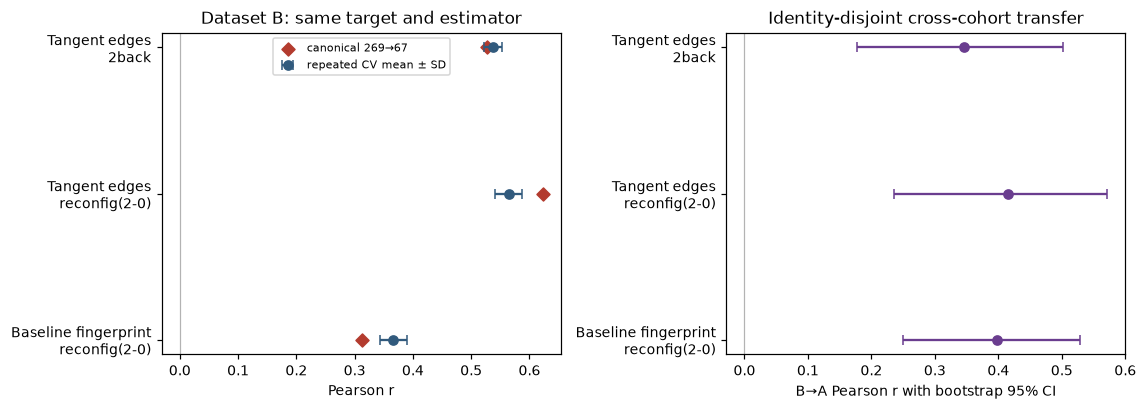

In [9]:
# Aggregate comparison only: no subject-level points are plotted or saved
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
labels = lambda frame: [f"{method}\n{representation}" for method, representation
                        in zip(frame["method"], frame["representation"], strict=True)]

acc_plot = INTERNAL.query("target == 'acc_2bk'").reset_index(drop=True)
positions = np.arange(len(acc_plot))
axes[0].errorbar(acc_plot["cv_r_mean"], positions, xerr=acc_plot["cv_r_sd"], fmt="o", capsize=3,
                 color="#315a7d", label="repeated CV mean ± SD")
axes[0].scatter(acc_plot["heldout_r"], positions, marker="D", color="#b33b2e", label="canonical 269→67")
axes[0].set_yticks(positions, labels(acc_plot))
axes[0].set_xlabel("Pearson r")
axes[0].set_title("Dataset B: same target and estimator")
axes[0].legend(fontsize=7)

positions = np.arange(len(EXTERNAL))
axes[1].errorbar(EXTERNAL["r"], positions, fmt="o", capsize=3, color="#6a3d8f",
                 xerr=np.vstack([EXTERNAL["r"] - EXTERNAL["ci_low"], EXTERNAL["ci_high"] - EXTERNAL["r"]]))
axes[1].set_yticks(positions, labels(EXTERNAL))
axes[1].set_xlabel("B→A Pearson r with bootstrap 95% CI")
axes[1].set_title("Identity-disjoint cross-cohort transfer")

for axis in axes:
    axis.axvline(0, color="0.7", lw=0.8)
plt.tight_layout()
fig.savefig(ARTIFACTS / "fig_tangent_benchmark.png", bbox_inches="tight")
plt.show()

## Decision

The rule is applied to the reconfiguration candidate first, because that is the project's stated
question; the 2-back-only variant is reported separately rather than substituted for it.

In [10]:
# Generate the aggregate report and the explicit recommendation
def markdown_table(frame: pd.DataFrame) -> str:
    """Pipe table for the report: ``DataFrame.to_markdown`` needs the optional ``tabulate``."""
    def cell(value: object) -> str:
        return f"{value:.4f}" if isinstance(value, (float, np.floating)) else str(value)

    lines = [" | ".join(frame.columns), " | ".join(["---"] * frame.shape[1])]
    lines += [" | ".join(cell(value) for value in row) for row in frame.itertuples(index=False)]
    return "\n".join(f"| {line} |" for line in lines)


def row_of(frame: pd.DataFrame, method: str, representation: str, **extra) -> pd.Series:
    """Single result row, so the decision rule never depends on positional indexing."""
    query = {"method": method, "representation": representation, **extra}
    mask = np.logical_and.reduce([frame[key] == value for key, value in query.items()])
    return frame[mask].iloc[0]


internal_reconfig = row_of(INTERNAL, "Tangent edges", "reconfig(2-0)", target="acc_2bk")
reconfig_external = row_of(EXTERNAL, "Tangent edges", "reconfig(2-0)")
two_back_external = row_of(EXTERNAL, "Tangent edges", "2back")
baseline_internal = row_of(INTERNAL, "Baseline fingerprint", "reconfig(2-0)", target="acc_2bk")
baseline_external = row_of(EXTERNAL, "Baseline fingerprint", "reconfig(2-0)")
baseline_external_r = float(baseline_external["r"])
competitive = float(reconfig_external["r"]) >= baseline_external_r
delta_low, delta_high = float(reconfig_external["delta_ci_low"]), float(reconfig_external["delta_ci_high"])

# Interpretation figures, derived so the prose cannot drift from the tables on a re-run.
internal_gain = float(internal_reconfig["cv_r_mean"]) - float(baseline_internal["cv_r_mean"])
external_gain = float(reconfig_external["r"]) - baseline_external_r
resolution = (delta_high - delta_low) / 2

if float(internal_reconfig["perm_p"]) > 0.05 or float(reconfig_external["perm_p"]) > 0.05:
    DECISION = ("DO NOT ADOPT: tangent reconfiguration did not beat the prespecified permutation "
                "null both internally and in identity-disjoint B-to-A transfer.")
elif competitive and delta_low > 0.0:
    DECISION = ("ADOPT AS A CANDIDATE FOR TEAM REVIEW: tangent reconfiguration reproduced the "
                "internal gain, beat the external null, and its paired bootstrap delta over "
                "baseline was strictly positive.")
elif competitive:
    DECISION = ("POSTPONE ADOPTION: tangent reconfiguration beat the external null and was not "
                "worse in point estimate, but the paired improvement over baseline is uncertain.")
elif delta_high < 0.0:
    DECISION = ("DO NOT ADOPT: tangent reconfiguration was significantly worse than baseline under "
                "the paired B-to-A bootstrap.")
else:
    DECISION = ("POSTPONE ADOPTION: tangent reconfiguration fell below the B-to-A baseline in point "
                "estimate, but the paired delta interval is inconclusive.")

KEEP_NOTE = (
    "Tangent FC is forwarded to the team as an adoption candidate."
    if DECISION.startswith("ADOPT")
    else "The project keeps the 78-feature fingerprint, which carries the network-level "
         "interpretation the analysis is built on, and records tangent FC as a tested alternative "
         "rather than an unexplored one.")

TWO_BACK_NOTE = (
    "The 2-back-only tangent alternative is externally competitive and significant, but adopting it "
    "would change the project's reconfiguration estimand."
    if float(two_back_external["perm_p"]) <= 0.05 and float(two_back_external["r"]) >= baseline_external_r
    else "The 2-back-only tangent alternative does not supply a separately adoptable solution under "
         "the same external rule.")

INTERPRETATION = f"""## Interpretation

- Both representations predict working-memory performance in the identity-disjoint cohort
  (permutation p = {float(baseline_external["perm_p"]):.4f} and {float(reconfig_external["perm_p"]):.4f}).
- Tangent FC gains {internal_gain:+.3f} r over the baseline in internal CV, but {external_gain:+.3f} r
  in cross-cohort transfer: the internal advantage does not reappear out of cohort.
- With {int(reconfig_external["test_n"])} external subjects the paired bootstrap resolves differences
  no smaller than about {resolution:.2f} r, so it cannot rank the two representations. The absent gain
  is not evidence that they perform equally.
- {KEEP_NOTE}"""

REPORT = f"""# Tangent-space FC benchmark: executed findings

**Status:** sandbox candidate; not promoted to `pipeline/` or to the team abstract.
**Protocol:** {PROTOCOL} · {len(SEEDS)} CV seeds · {N_PERM} permutations · {N_BOOT} bootstrap resamples.
Generated by [`06_tangent_fc_benchmark.ipynb`](../06_tangent_fc_benchmark.ipynb). Edit the notebook, not this file.

## Result

{DECISION}

{TWO_BACK_NOTE}

### Internal dataset-B benchmark

{markdown_table(INTERNAL)}

### CV restricted to the canonical 269 development subjects

{markdown_table(STRICT_CV)}

### Identity-disjoint B-to-A transfer

{markdown_table(EXTERNAL)}

{INTERPRETATION}

## What the code computes

- All methods share the delayed event windows, targets, folds, train-fitted scaling and RidgeCV grid.
- The baseline averages Pearson FC into 78 within/between-network features.
- The candidate uses {N_EDGES:,} off-diagonal log-Euclidean edges from Ledoit-Wolf covariance.
- B-to-A training excludes every identity found in A; learned state is fitted on 301 B-only rows.

## Limitations

1. Historical repeated CV used all 336 B participants, so the separate 67 score is not an untouched
   post-selection confirmation.
2. The internal p-value is an out-of-fold association permutation against fixed predictions, not a
   model-refit null. The B-to-A permutation is clean, because A labels never fit the model.
3. Dataset A was already inspected during pipeline development, so B-to-A is identity-disjoint
   exploratory transfer rather than pristine confirmation.
4. Both cohorts are HCP samples from one acquisition domain: not cross-site or clinical validation.
5. Family identifiers are unavailable, and condition-correlation FC may retain task-evoked
   coactivation.
6. Tangent FC costs {N_EDGES:,} features per subject, reducing interpretability and increasing
   memory relative to the 78-feature baseline.
7. DVARS, BOLD-variance and tangent-parametrisation sensitivity are reported by the separate audited
   benchmark and were not rerun here.

## Cost

No new dependency. The ID-free cache is {sum(p.stat().st_size for p in CACHE.glob('*') if p.is_file()) / 1024 ** 2:.1f} MiB
and this run took {(time.perf_counter() - NOTEBOOK_STARTED) / 60:.1f} min.

## Primary references (Vancouver)

1. Varoquaux G, Baronnet F, Kleinschmidt A, Fillard P, Thirion B. Detection of brain
   functional-connectivity difference in post-stroke patients using group-level covariance modeling.
   MICCAI. 2010;13(Pt 1):200-208. doi:10.1007/978-3-642-15705-9_25.
2. Dadi K, Rahim M, Abraham A, et al. Benchmarking functional connectome-based predictive models for
   resting-state fMRI. NeuroImage. 2019;192:115-134. doi:10.1016/j.neuroimage.2019.02.062.
3. Avery EW, Yoo K, Rosenberg MD, et al. Distributed patterns of functional connectivity predict
   working memory performance in novel healthy and memory-impaired individuals. J Cogn Neurosci.
   2020;32(2):241-255. doi:10.1162/jocn_a_01487.
4. Ledoit O, Wolf M. A well-conditioned estimator for large-dimensional covariance matrices.
   J Multivar Anal. 2004;88(2):365-411. doi:10.1016/S0047-259X(03)00096-4.
"""

REPORT_PATH = JAIME / "docs" / "06_tangent_benchmark_report.md"
REPORT_PATH.write_text(REPORT)
# Verdict and interpretation only: limitations, cost and references stay in the report file
# rather than being re-rendered from the f-string a few lines above.
display(Markdown(f"**{DECISION}**\n\n{TWO_BACK_NOTE}\n\n{INTERPRETATION}\n\n"
                 f"Full report -> `{REPORT_PATH.relative_to(ROOT)}`"))

**POSTPONE ADOPTION: tangent reconfiguration beat the external null and was not worse in point estimate, but the paired improvement over baseline is uncertain.**

The 2-back-only tangent alternative does not supply a separately adoptable solution under the same external rule.

## Interpretation

- Both representations predict working-memory performance in the identity-disjoint cohort
  (permutation p = 0.0010 and 0.0010).
- Tangent FC gains +0.198 r over the baseline in internal CV, but +0.016 r
  in cross-cohort transfer: the internal advantage does not reappear out of cohort.
- With 100 external subjects the paired bootstrap resolves differences
  no smaller than about 0.19 r, so it cannot rank the two representations. The absent gain
  is not evidence that they perform equally.
- The project keeps the 78-feature fingerprint, which carries the network-level interpretation the analysis is built on, and records tangent FC as a tested alternative rather than an unexplored one.

Full report -> `sandbox/jaime/docs/06_tangent_benchmark_report.md`